In [ ]:
from ultralytics import YOLO
import torch
import os
import time
import random
import cv2
import matplotlib.pyplot as plt

In [ ]:
torch.cuda.empty_cache()

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("lywang777/urpc2020")

print("Dataset downloaded at:", path)

base_path = os.path.join(path, "URPC2020")
print("Base path:", base_path)

Dataset downloaded at: C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1
Base path: C:\Users\pb875\.cache\kagglehub\datasets\lywang777\urpc2020\versions\1\URPC2020


In [ ]:
import os

train_img = os.path.join(base_path, "train/images")
val_img   = os.path.join(base_path, "valid/images")
test_img  = os.path.join(base_path, "test/images")

train_lbl = os.path.join(base_path, "train/labels")
val_lbl   = os.path.join(base_path, "valid/labels")

print("Train images:", len(os.listdir(train_img)))
print("Val images:", len(os.listdir(val_img)))
print("Test images:", len(os.listdir(test_img)))

Train images: 5543
Val images: 1200
Test images: 800


In [ ]:
import yaml

data = {
    "path": base_path,
    "train": train_img,
    "val": val_img,
    "test": test_img,
    "names": ["holothurian", "echinus", "scallop", "starfish"]
}

with open("data.yaml", "w") as f:
    yaml.dump(data, f)

print("data.yaml created")

data.yaml created


In [ ]:
model = YOLO("yolov8s.pt")

In [ ]:
model.train(
    data="data.yaml",
    epochs=60,
    imgsz=512,
    batch=32,
    device=0,
    workers=4,
    cache="ram",
    amp=True,
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    mosaic=0.5,
    mixup=0.05,
    close_mosaic=10,
    hsv_h=0.02,
    hsv_s=0.5,
    hsv_v=0.4,
    fliplr=0.5,
    scale=0.3,
    translate=0.1,
    degrees=5.0,
    patience=20,
    project="runs/detect",
    name="final_model",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.204  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.5, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=final_model, nbs=64, nms=False, opse

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001EEA8D789E0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [ ]:
from ultralytics import YOLO


model = YOLO("runs/detect/final_model/weights/best.pt")

model.train(
    data="data.yaml",
    epochs=40,
    imgsz=512,
    batch=16,
    device=0,
    workers=2,
    cache=False,
    amp=True,
    optimizer="AdamW",
    lr0=0.0001,
    cos_lr=True,
    mosaic=0.3,
    mixup=0.02,
    close_mosaic=5,
    hsv_h=0.02,
    hsv_s=0.5,
    hsv_v=0.4,
    fliplr=0.5,
    scale=0.3,
    translate=0.1,
    degrees=5.0,
    patience=15,
    project="runs/detect",
    name="final_model_v2",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.204  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.5, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.02, mode=train, model=runs/detect/final_model/weights/best.pt, momentum=0.937, mosaic=0.3, multi_scale=False, name=final

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F06CADBD70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [ ]:
from ultralytics import YOLO


model = YOLO("runs/detect/final_model/weights/best.pt")
model.export(
    format="engine",
    half=True,
    imgsz=512,
    device=0
)


model_trt = YOLO("runs/detect/final_model/weights/best.engine")
model_trt.benchmark(imgsz=512, device=0, half=True)

Ultralytics 8.3.204  Python-3.12.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'runs\detect\final_model\weights\best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 8, 5376) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.67', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.2/16.4 MB 6.3 MB/s eta 0:00:03
   --- ------------------------------------ 1.5/16.4 MB 18.9 MB/s eta 0:00:01
   -------- ------------------------------- 3.5/16.4 MB 27.6 MB/s eta 0:00:01
   ----------- ---------------------------- 4.9/16.4 MB 28.6 MB/s eta 0:00:01
   ----

 Loading model: /content/best (1).pt
Please upload your test images (.jpg, .png, etc.):


Saving 000784.jpg to 000784 (1).jpg

Processing 1 images...


image 1/1 /content/000784 (1).jpg: 192x320 5 echinuss, 1 starfish, 41.8ms
Speed: 1.1ms preprocess, 41.8ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 320)


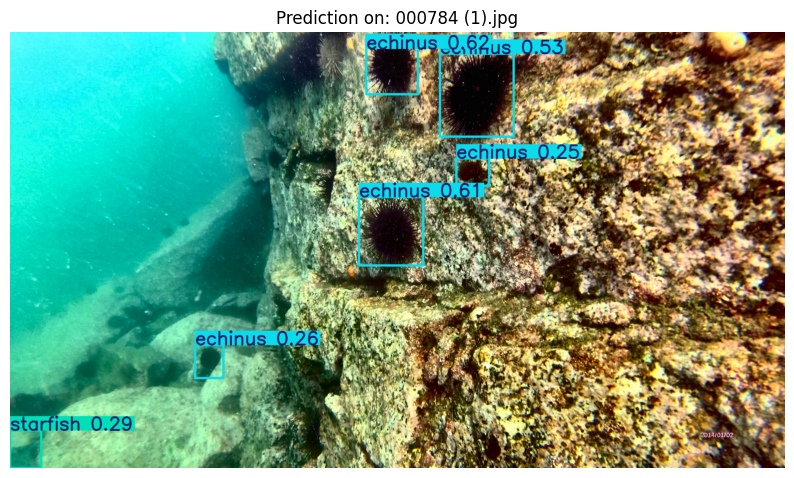

In [ ]:

!pip install ultralytics

import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files


!pip install opencv-python-headless

import cv2

EXP17_MODEL_PATH = "/content/best (1).pt"

if not os.path.exists(EXP17_MODEL_PATH):
    print(f" Model not found at: {EXP17_MODEL_PATH}")
else:

    print(f" Loading model: {EXP17_MODEL_PATH}")
    model_exp17 = YOLO(EXP17_MODEL_PATH)


    print("Please upload your test images (.jpg, .png, etc.):")
    uploaded = files.upload()

    if uploaded:
        print(f"\nProcessing {len(uploaded)} images...\n")
        for filename in uploaded.keys():

            results = model_exp17.predict(source=filename, conf=0.25, save=False)


            plotted_img = results[0].plot()
            plotted_img_rgb = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 8))
            plt.imshow(plotted_img_rgb)
            plt.title(f"Prediction on: {filename}")
            plt.axis('off')
            plt.show()
    else:
        print("No files uploaded.")